# Correct DST k=10: patient-paired statistical analysis

This notebook rebuilds the five-model comparison with the correct GLAM-embedding DST-Prototype k=10. The primary inference is paired on the same independent test patients; image-level results retain patient clustering.

## Analysis contract

- Correct DST source: `G:\\611\\glam\\proto_embedding_rerun\\DST_k_10`
- Primary unit: patient; patient score = mean image probability, patient label = maximum image label.
- Primary test: paired DeLong, four prespecified DST-vs-baseline comparisons, Holm correction.
- Uncertainty: 20,000 paired stratified bootstraps; robustness: 20,000 paired score-swap permutations.
- Image sensitivity analysis: stratified patient-cluster bootstrap and patient-cluster score swap.
- Seed: `20260728`; all tests are two-sided with alpha 0.05.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

OUTPUT_DIR = Path.cwd()
from analysis import run_analysis
results = run_analysis()

[1/7] Loading and validating five model prediction sources


[2/7] Patient-stratified bootstrap: 20,000 resamples


[3/7] Patient-cluster image bootstrap: 20,000 resamples


[4/7] Patient-level paired score-swap permutation: 20,000 per comparison


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


...

[Parallel(n_jobs=4)]: Done 2 out of 4 | elapsed:    7.4s remaining:    7.4s
[Parallel(n_jobs=4)]: Done 4 out of 4 | elapsed:    7.4s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done 2 out of 4 | elapsed:   59.7s remaining:   59.7s


[6/7] Building result tables, paper text, and figures


[Parallel(n_jobs=4)]: Done 4 out of 4 | elapsed:  1.0min finished


[7/7] Analysis complete


## Forced data and source validation

In [2]:
display(pd.DataFrame([results['validation']]).T.rename(columns={0: 'observed'}))
display(results['source_audit'])

,observed
common_images,8409.000000
common_patients,862.000000
positive_patients,19.000000
negative_patients,843.000000
label_conflicts,0.000000
duplicate_common_keys,0.000000
missing_predictions,0.000000
nonfinite_predictions,0.000000
dst_full_images,8433.000000
dst_full_patient_auc,0.864831


,model,source_files,source_test_rows,source_patients,duplicate_keys,missing_scores,nonfinite_scores,aggregation,common_rows,common_patients
0,DST k=10,/mnt/g/611/glam/proto_embedding_rerun/DST_k_10...,8433,862,0,0,0,existing five-fold ensemble file,8409,862
1,GLAM,/mnt/g/611/612/glam-origin/glam-origin/glam_kf...,8409,862,0,0,0,existing five-fold ensemble file,8409,862
2,Mammo-FM,/mnt/g/611/612/613/Mammo-FM/data_predictions_e...,8433,862,0,0,0,existing five-fold ensemble file,8409,862
3,Mammo-CLIP,/mnt/g/611/612/613/lr_5e-05_epochs_25_weighted...,8409,862,0,0,0,existing five-fold ensemble file,8409,862
4,MIL,/mnt/g/611/612/MIL-Origin/MIL-Origin/2026-06-0...,8409,862,0,0,0,arithmetic mean of five saved test probabiliti...,8409,862


The analysis aborts unless the common cohort is exactly 8,409 images, 862 patients, and 19 positive patients; label conflicts, duplicate keys, missing predictions, and non-finite predictions must all equal zero. It also aborts unless the correct DST patient AUROC reproduces 0.864831 on all 8,433 images and 0.864581 on the common cohort.

## AUROC, AUPRC, confidence intervals, and descriptive threshold metrics

In [3]:
cols = ['grain','model','n','positives','auc','auc_ci95_low','auc_ci95_high','auprc','auprc_ci95_low','auprc_ci95_high','sensitivity_0p5','specificity_0p5','bacc_0p5','f1_0p5']
display(results['model_metrics'][cols].round(6))

,grain,model,n,positives,auc,auc_ci95_low,auc_ci95_high,auprc,auprc_ci95_low,auprc_ci95_high,sensitivity_0p5,specificity_0p5,bacc_0p5,f1_0p5
0,patient,DST k=10,862,19,0.864581,0.802021,0.918526,0.126512,0.072697,0.280008,0.315789,0.941874,0.628832,0.162162
1,patient,GLAM,862,19,0.671974,0.538364,0.792347,0.101675,0.031914,0.237478,0.315789,0.830368,0.573079,0.071429
2,patient,Mammo-FM,862,19,0.862334,0.792158,0.922898,0.111337,0.073486,0.201162,0.526316,0.914591,0.720453,0.198020
3,patient,Mammo-CLIP,862,19,0.828183,0.730972,0.910283,0.106666,0.066512,0.200419,0.526316,0.927639,0.726978,0.222222
4,patient,MIL,862,19,0.871824,0.809699,0.924518,0.130271,0.075880,0.277938,0.421053,0.927639,0.674346,0.181818
5,image_clustered,DST k=10,8409,66,0.800619,0.733162,0.861437,0.042130,0.021608,0.080183,0.515152,0.876543,0.695847,0.060177
6,image_clustered,GLAM,8409,66,0.699369,0.588888,0.786137,0.030731,0.013988,0.075238,0.409091,0.876663,0.642877,0.048128
7,image_clustered,Mammo-FM,8409,66,0.855220,0.788452,0.907085,0.045152,0.023090,0.095686,0.606061,0.866954,0.736507,0.065789
8,image_clustered,Mammo-CLIP,8409,66,0.858581,0.759466,0.926442,0.055809,0.030239,0.115763,0.560606,0.944025,0.752315,0.129825
9,image_clustered,MIL,8409,66,0.825466,0.766776,0.874312,0.060344,0.028292,0.109717,0.530303,0.875345,0.702824,0.061350


## Patient-level primary paired inference

In [4]:
display(results['patient_tests'].round(6))

,comparison,baseline,dst_auc_delong,baseline_auc_delong,delta_auc,delong_variance_delta,delong_z,p_delong_raw,delta_auc_ci95_low,delta_auc_ci95_high,delta_auprc,bootstrap_mean_delta_auprc,delta_auprc_ci95_low,delta_auprc_ci95_high,p_permutation_auc_raw,p_permutation_auprc_raw,p_delong_holm,p_permutation_auc_holm,p_permutation_auprc_holm,significant_delong_holm_0p05
0,DST k=10 vs GLAM,GLAM,0.864581,0.671974,0.192608,0.004430,2.893910,0.003805,0.074168,0.327716,0.024837,0.039888,-0.025438,0.105610,0.001950,0.372381,0.015219,0.0078,1.0,True
1,DST k=10 vs Mammo-FM,Mammo-FM,0.864581,0.862334,0.002248,0.000555,0.095369,0.924022,-0.042018,0.048136,0.015175,0.022401,-0.057280,0.131937,0.955202,0.669217,1.000000,1.0000,1.0,False
2,DST k=10 vs Mammo-CLIP,Mammo-CLIP,0.864581,0.828183,0.036399,0.001117,1.088942,0.276180,-0.023662,0.103890,0.019846,0.026840,-0.053198,0.134381,0.458327,0.564672,0.828539,1.0000,1.0,False
3,DST k=10 vs MIL,MIL,0.864581,0.871824,-0.007242,0.000770,-0.260973,0.794113,-0.056317,0.048573,-0.003759,-0.003661,-0.079290,0.071867,0.875956,0.944103,1.000000,1.0000,1.0,False


DeLong p values with Holm correction define the primary significance conclusions. The paired score-swap permutation is a robustness check for the small positive-patient count, not a replacement primary test.

## Image-level patient-cluster sensitivity analysis

In [5]:
display(results['image_tests'].round(6))

,comparison,baseline,delta_auc,bootstrap_mean_delta_auc,delta_auc_ci95_low,delta_auc_ci95_high,delta_auprc,bootstrap_mean_delta_auprc,delta_auprc_ci95_low,delta_auprc_ci95_high,p_permutation_auc_raw,p_permutation_auprc_raw,p_permutation_auc_holm,p_permutation_auprc_holm,significant_auc_holm_0p05,significant_auprc_holm_0p05
0,DST k=10 vs GLAM,GLAM,0.101250,0.103724,0.008060,0.198394,0.011400,0.009527,-0.024239,0.039935,0.069597,0.241688,0.208790,0.966752,False,False
1,DST k=10 vs Mammo-FM,Mammo-FM,-0.054601,-0.053976,-0.099373,-0.004923,-0.003021,-0.003913,-0.037411,0.018760,0.042048,0.900305,0.168192,1.000000,False,False
2,DST k=10 vs Mammo-CLIP,Mammo-CLIP,-0.057963,-0.056261,-0.124471,0.028179,-0.013679,-0.018886,-0.060363,0.009338,0.123394,0.336483,0.246788,1.000000,False,False
3,DST k=10 vs MIL,MIL,-0.024848,-0.024470,-0.075095,0.024568,-0.018213,-0.018449,-0.061236,0.007852,0.389731,0.504725,0.389731,1.000000,False,False


## Patient-level ROC curves

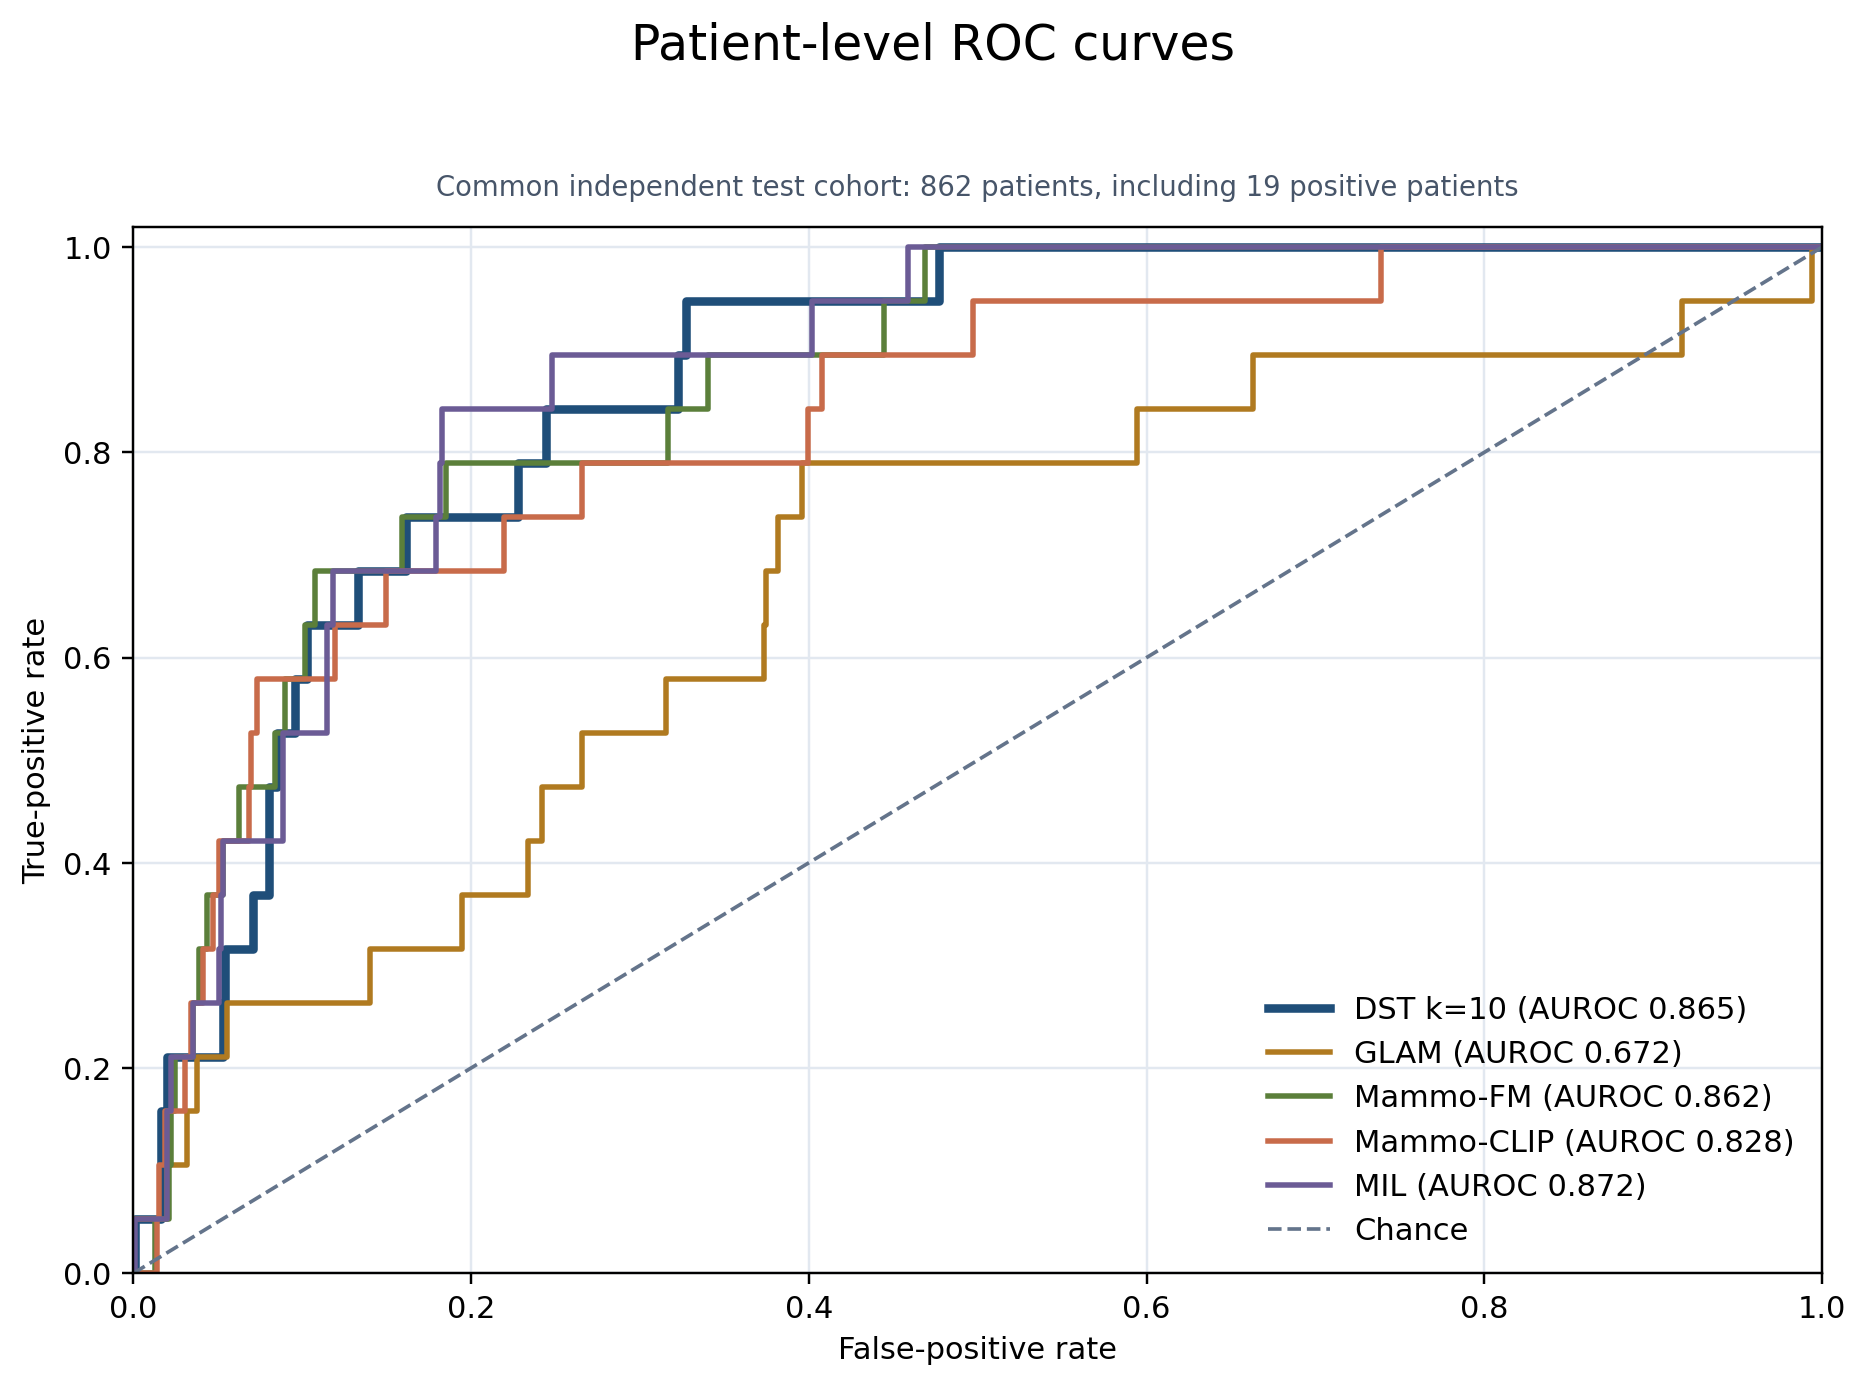

In [6]:
display(Image(filename=str(OUTPUT_DIR / 'patient_roc.png')))

## Paired ΔAUROC forest plot

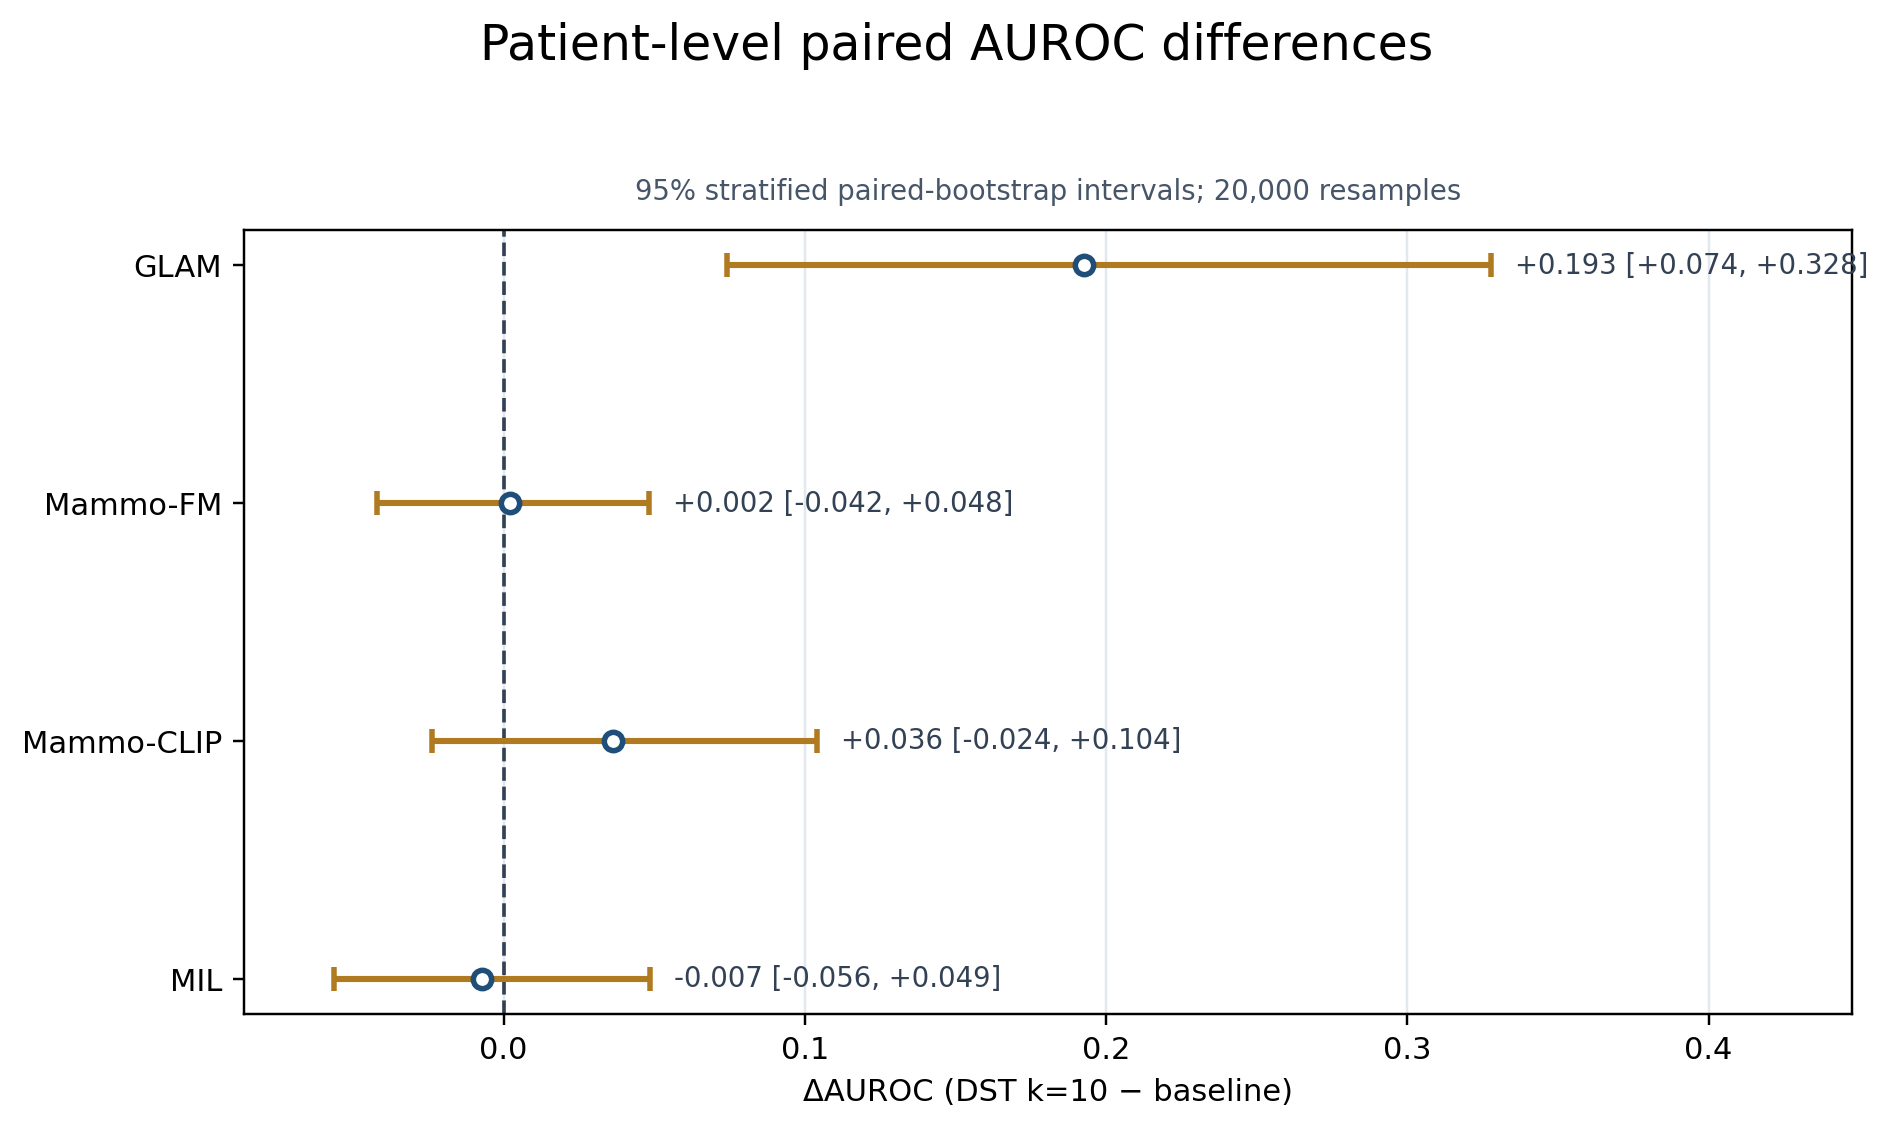

In [7]:
display(Image(filename=str(OUTPUT_DIR / 'patient_delta_auc_forest.png')))

## Paper-ready Statistical Analysis

In [8]:
display(Markdown((OUTPUT_DIR / 'statistical_analysis_methods_en.md').read_text(encoding='utf-8')))

## Statistical Analysis

All five models were evaluated on the same independent test cohort of 8,409 mammograms from 862 patients (19 cancer-positive patients). Existing five-fold ensemble predictions were used for DST-Prototype k=10, GLAM, Mammo-FM, and Mammo-CLIP; for MIL, the five saved test probabilities were averaged for each image. Analyses were restricted to image keys available for all models. Patient-level scores, used for the primary analysis, were calculated as the mean probability across all images from a patient, and patient labels were defined by the maximum image label.

Patient-level AUROC and area under the precision-recall curve (AUPRC) were reported with 95% confidence intervals from 20,000 patient-stratified bootstrap resamples. Differences in correlated AUROCs between DST k=10 and each prespecified baseline were tested using two-sided paired DeLong tests. Paired bootstrap confidence intervals for ΔAUROC (DST minus baseline) used identical positive- and negative-patient resampling indices for all models. As a robustness analysis for the small number of positive patients, two-sided paired score-swap permutation tests were performed with 20,000 permutations. DeLong p values were adjusted across the four prespecified comparisons using the Holm method and defined the primary significance conclusions.

At image level, patient was retained as the sampling cluster: all images from a resampled patient entered the bootstrap sample together, and score swaps were applied to the complete patient cluster. Twenty thousand stratified cluster-bootstrap resamples were used for confidence intervals for ΔAUROC and ΔAUPRC, and 20,000 patient-cluster score-swap permutations were used for secondary p values, with separate Holm correction across the four image-level comparisons. All tests were two-sided with α=0.05. Sensitivity, specificity, balanced accuracy, and F1 score at a fixed threshold of 0.5 were descriptive only. The random seed was 20260728. Training-fold identity was not required because every inferential comparison was paired on the same independent test patients rather than across training folds.


## Paper-ready Results

In [9]:
display(Markdown((OUTPUT_DIR / 'results_en.md').read_text(encoding='utf-8')))

## Results

The common evaluation cohort contained 8,409 images from 862 patients, including 19 positive and 843 negative patients. No label conflicts, duplicate patient-image keys, missing predictions, or non-finite scores were detected. The prespecified correct DST k=10 predictions reproduced a patient-level AUROC of 0.864831 on all 8,433 images and 0.864581 on the common cohort.

Patient-level discrimination was: DST k=10: AUROC 0.865 (95% CI 0.802–0.919) and AUPRC 0.127 (95% CI 0.073–0.280); GLAM: AUROC 0.672 (95% CI 0.538–0.792) and AUPRC 0.102 (95% CI 0.032–0.237); Mammo-FM: AUROC 0.862 (95% CI 0.792–0.923) and AUPRC 0.111 (95% CI 0.073–0.201); Mammo-CLIP: AUROC 0.828 (95% CI 0.731–0.910) and AUPRC 0.107 (95% CI 0.067–0.200); MIL: AUROC 0.872 (95% CI 0.810–0.925) and AUPRC 0.130 (95% CI 0.076–0.278). In the primary paired comparisons, versus GLAM, ΔAUROC=+0.193 (95% CI +0.074 to +0.328; DeLong p=0.0038, Holm-adjusted p=0.0152; significant); versus Mammo-FM, ΔAUROC=+0.002 (95% CI -0.042 to +0.048; DeLong p=0.9240, Holm-adjusted p=1.0000; not significant); versus Mammo-CLIP, ΔAUROC=+0.036 (95% CI -0.024 to +0.104; DeLong p=0.2762, Holm-adjusted p=0.8285; not significant); versus MIL, ΔAUROC=-0.007 (95% CI -0.056 to +0.049; DeLong p=0.7941, Holm-adjusted p=1.0000; not significant). The patient-level permutation analysis gave the same significance classification as the DeLong-Holm analysis.

The image-level cluster analysis was treated as sensitivity evidence because images from the same patient are not independent. Its confidence intervals and cluster-permutation p values are reported in the accompanying table and do not replace the patient-level primary conclusion.


## 中文结论

In [10]:
display(Markdown((OUTPUT_DIR / 'summary_zh.md').read_text(encoding='utf-8')))

# 中文结论

这次分析已改用正确的 GLAM embedding DST-Prototype k=10，并且严格限制在五个模型共同拥有的 8,409 张图像、862 名患者上，其中阳性患者 19 名。标签冲突、重复键、预测缺失和非有限值均为 0。

正确 DST 的患者级 AUROC 在全 8,433 张图像上复现为 0.864831，在共同 8,409 张图像上复现为 0.864581。论文主分析以患者为单位，用相关 ROC 的配对 DeLong 检验，并对四项预设比较做 Holm 校正；训练折不需要相同，因为统计配对发生在同一批独立测试患者上，而不是比较训练折。

Holm 校正后显著优于 DST 的 baseline：无（比较方向固定为 DST 减 baseline）。DST 相对其达到显著优势的 baseline：GLAM。未达到显著差异的比较：Mammo-FM、Mammo-CLIP、MIL。由于只有 19 名阳性患者，应同时报告置信区间和患者级 score-swap permutation 稳健性结果，避免只依据单个 p 值作过强结论。

固定 0.5 阈值的敏感度、特异度、BACC 和 F1 仅作描述；图像级分析采用患者整簇重采样/置换，只作为敏感性分析，不作为论文主要显著性结论。


## Reproducibility notes

The companion `analysis.py` contains the full source-loading, common-key construction, DeLong, bootstrap, permutation, Holm correction, plotting, and output code. Bootstrap sampling is stratified by positive/negative patient; identical resampling weights are used for every model. No model is retrained, and no result is paired across different training folds.